In [2]:
# Membuat Direktori Baru
!hdfs dfs -mkdir -p /user/manggala/ecommerce/raw
!hdfs dfs -mkdir -p /user/manggala/ecommerce/processed

!hdfs dfs -ls /user/manggala/ecommerce

Found 2 items
drwxr-xr-x   - manggala supergroup          0 2026-09-09 21:53 /user/manggala/ecommerce/processed
drwxr-xr-x   - manggala supergroup          0 2026-09-09 21:53 /user/manggala/ecommerce/raw


In [5]:
# Mengunggah Data Mentah
!hdfs dfs -put transaksi_magelang.csv /user/manggala/ecommerce/raw/
!hdfs dfs -put transaksi_yogyakarta.csv /user/manggala/ecommerce/raw/
!hdfs dfs -put transaksi_semarang.csv /user/manggala/ecommerce/raw/

!hdfs dfs -ls /user/manggala/ecommerce/raw

put: `/user/manggala/ecommerce/raw/transaksi_magelang.csv': File exists
put: `/user/manggala/ecommerce/raw/transaksi_yogyakarta.csv': File exists
put: `/user/manggala/ecommerce/raw/transaksi_semarang.csv': File exists
Found 3 items
-rw-r--r--   1 manggala supergroup      12329 2026-09-09 21:55 /user/manggala/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 manggala supergroup      12154 2026-09-09 21:55 /user/manggala/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 manggala supergroup      12684 2026-09-09 21:55 /user/manggala/ecommerce/raw/transaksi_yogyakarta.csv


In [8]:
!pip install pyarrow fsspec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 198.9 kB/s  0:06:00 eta 0:00:020:00:06
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [fsspec]


In [2]:
# Membaca Kembali dan Menggabungkan Data
import pandas as pd
import os

# 1. Mengambil dan mengatur CLASSPATH Hadoop ke dalam environment Python
os.environ['CLASSPATH'] = os.popen('hadoop classpath --glob').read()

# 2. Mendefinisikan path HDFS
path_raw = "hdfs:///user/manggala/ecommerce/raw/"

# 3. Membaca data langsung dari HDFS
df_magelang = pd.read_csv(f"{path_raw}transaksi_magelang.csv")
df_yogyakarta = pd.read_csv(f"{path_raw}transaksi_yogyakarta.csv")
df_semarang = pd.read_csv(f"{path_raw}transaksi_semarang.csv")

# 4. Menggabungkan data
df_gabungan = pd.concat([df_magelang, df_yogyakarta, df_semarang], ignore_index=True)

print(df_gabungan['kota'].value_counts())

2026-09-09 22:08:37,259 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64


In [3]:
# 1. Menambahkan kolom 'total_pendapatan'
# Caranya dengan mengalikan kolom 'unit_terjual' dan 'harga_satuan' dari df_gabungan
df_gabungan['total_pendapatan'] = df_gabungan['unit_terjual'] * df_gabungan['harga_satuan']

# Menampilkan 5 baris pertama untuk memastikan kolom baru berhasil ditambahkan
print("Preview Data Gabungan Bersih:")
display(df_gabungan.head())


# 2. Membuat tabel ringkasan (groupby) per kota dan per kategori
# Kita kelompokkan berdasarkan kolom 'kota' dan 'kategori', 
# lalu jumlahkan (.sum) nilai pada kolom 'total_pendapatan'.
# .reset_index() digunakan agar hasil groupby kembali menjadi format tabel/DataFrame yang rapi.
df_ringkasan = df_gabungan.groupby(['kota', 'kategori'])['total_pendapatan'].sum().reset_index()

# Menampilkan hasil tabel ringkasan
print("\nPreview Tabel Ringkasan:")
display(df_ringkasan)


# 3. Menyimpan kedua DataFrame di atas sebagai file CSV di disk lokal (sementara)
# Gunakan index=False agar nomor urut baris tidak ikut tersimpan ke dalam file
df_gabungan.to_csv('data_gabungan_bersih.csv', index=False)
df_ringkasan.to_csv('ringkasan_kota_kategori.csv', index=False)

print("\n[INFO] Kedua file CSV berhasil disimpan di disk lokal laptop/VM.")

Preview Data Gabungan Bersih:


,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota,total_pendapatan
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang,50000
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang,175000
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang,175000
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang,150000
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang,700000



Preview Tabel Ringkasan:


,kota,kategori,total_pendapatan
0,Magelang,Elektronik,18775000
1,Magelang,Fashion,27750000
2,Magelang,Kesehatan & Kecantikan,17375000
3,Magelang,Makanan & Minuman,17525000
4,Magelang,Rumah Tangga,12200000
5,Semarang,Elektronik,21425000
6,Semarang,Fashion,26425000
7,Semarang,Kesehatan & Kecantikan,13525000
8,Semarang,Makanan & Minuman,19750000
9,Semarang,Rumah Tangga,10975000



[INFO] Kedua file CSV berhasil disimpan di disk lokal laptop/VM.


In [4]:
# 1. Mengunggah file data_gabungan_bersih.csv ke direktori processed
!hdfs dfs -put data_gabungan_bersih.csv /user/manggala/ecommerce/processed/

# 2. Mengunggah file ringkasan_kota_kategori.csv ke direktori processed
!hdfs dfs -put ringkasan_kota_kategori.csv /user/manggala/ecommerce/processed/

# 3. Menampilkan isi direktori /processed untuk membuktikan file sudah berhasil terunggah
print("Isi direktori /user/manggala/ecommerce/processed/ di HDFS:")
!hdfs dfs -ls /user/manggala/ecommerce/processed/

Isi direktori /user/manggala/ecommerce/processed/ di HDFS:
Found 2 items
-rw-r--r--   1 manggala supergroup      41257 2026-09-09 22:12 /user/manggala/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 manggala supergroup        530 2026-09-09 22:12 /user/manggala/ecommerce/processed/ringkasan_kota_kategori.csv


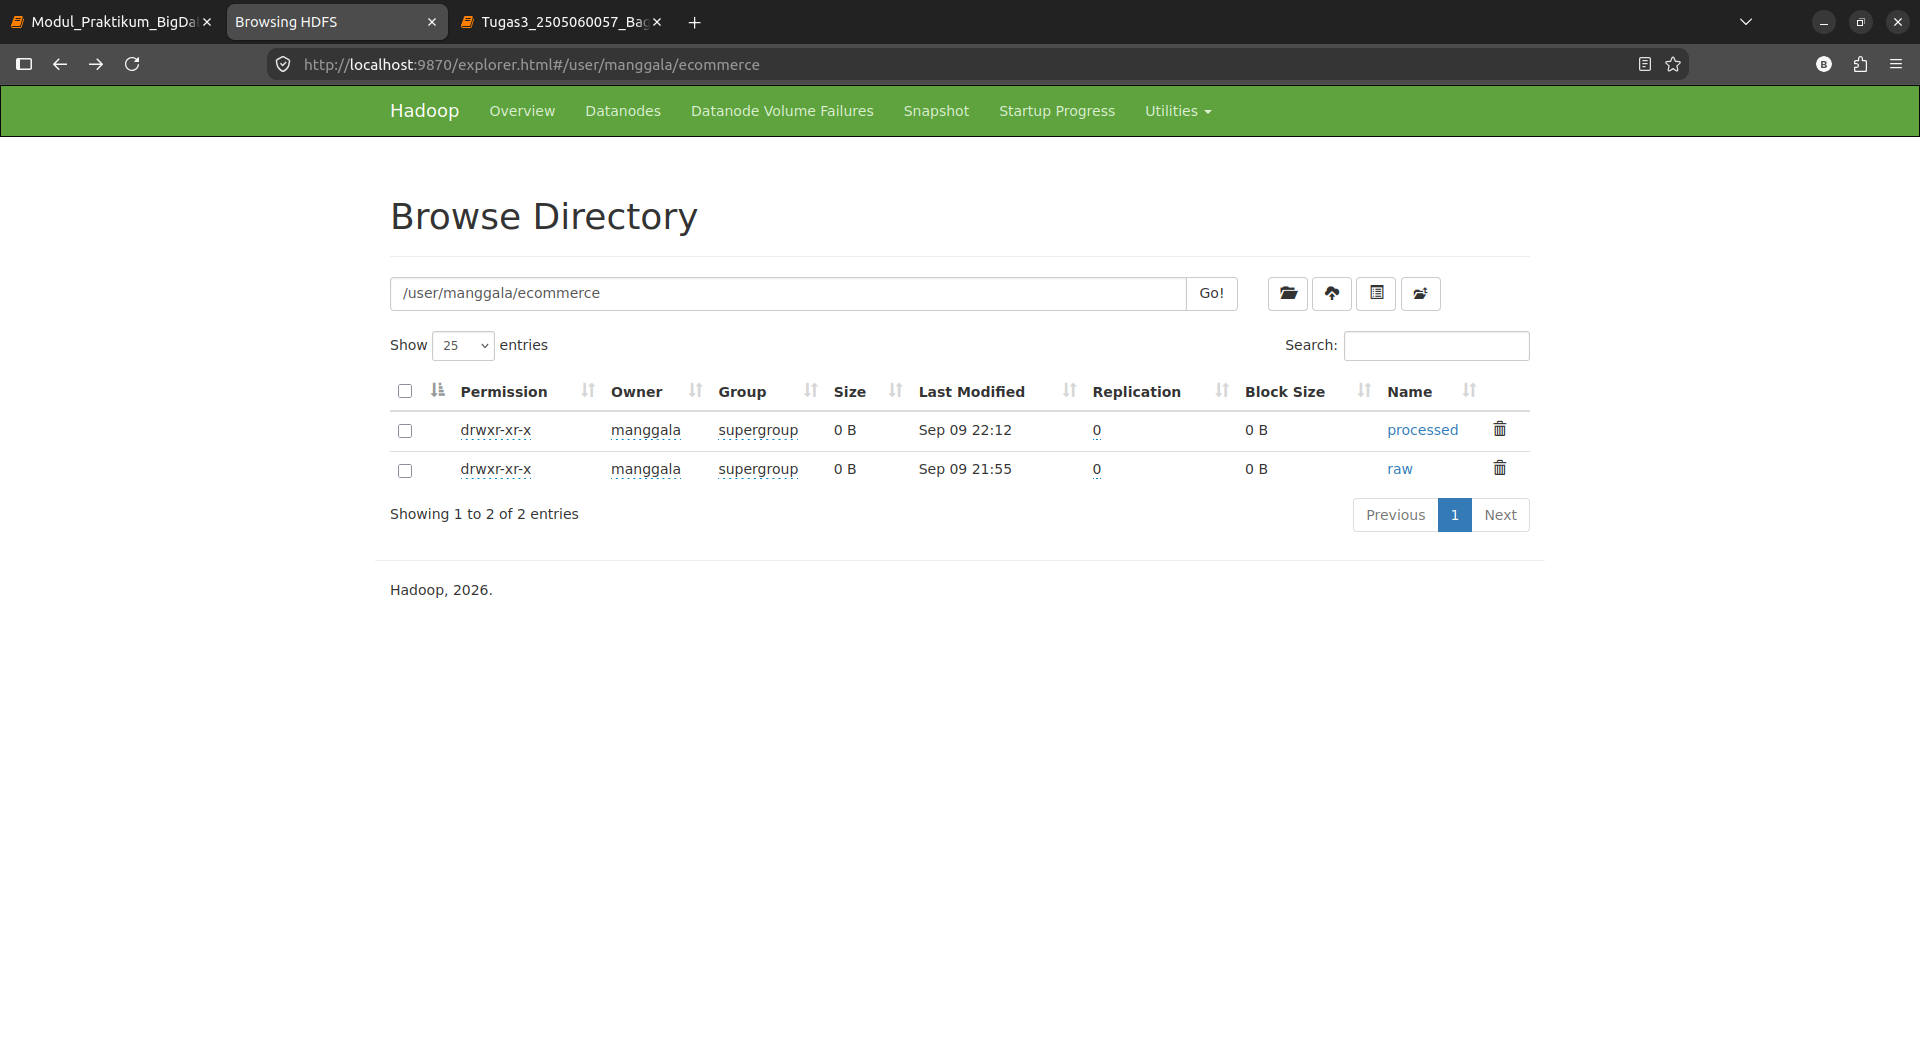

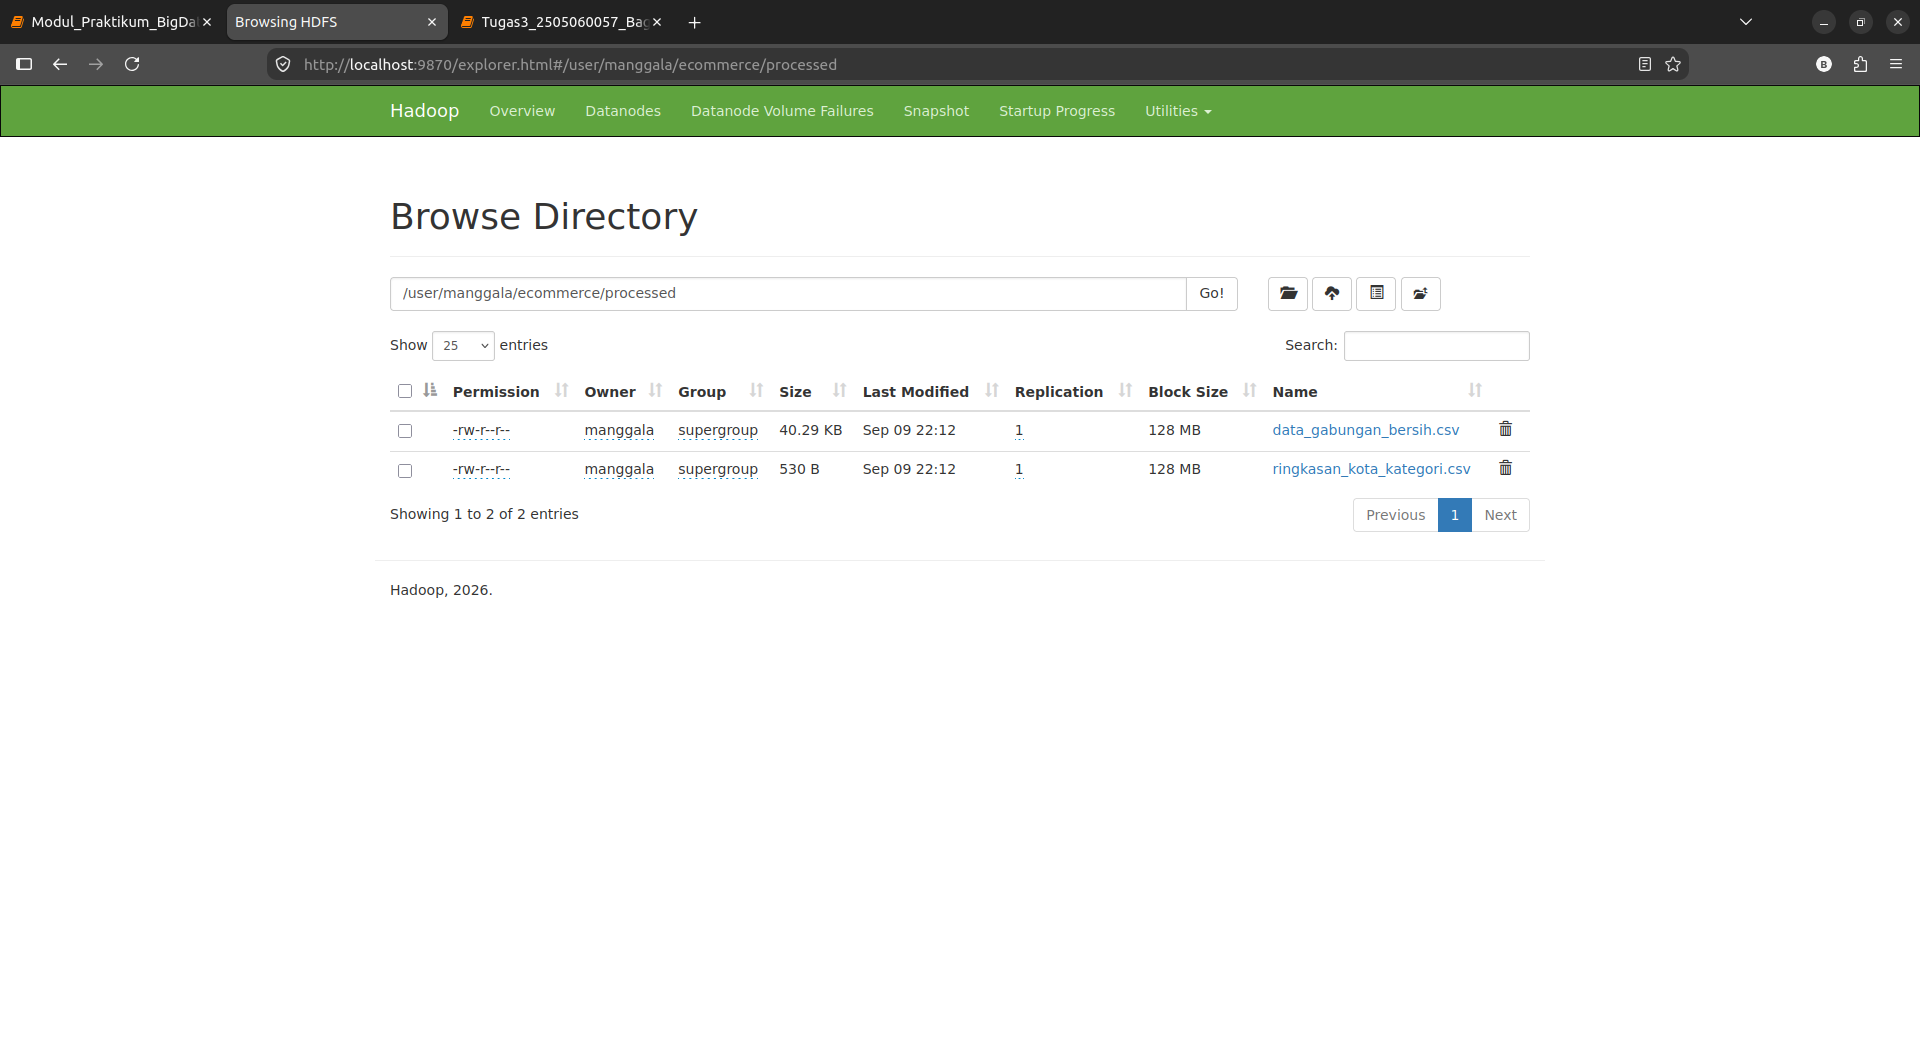

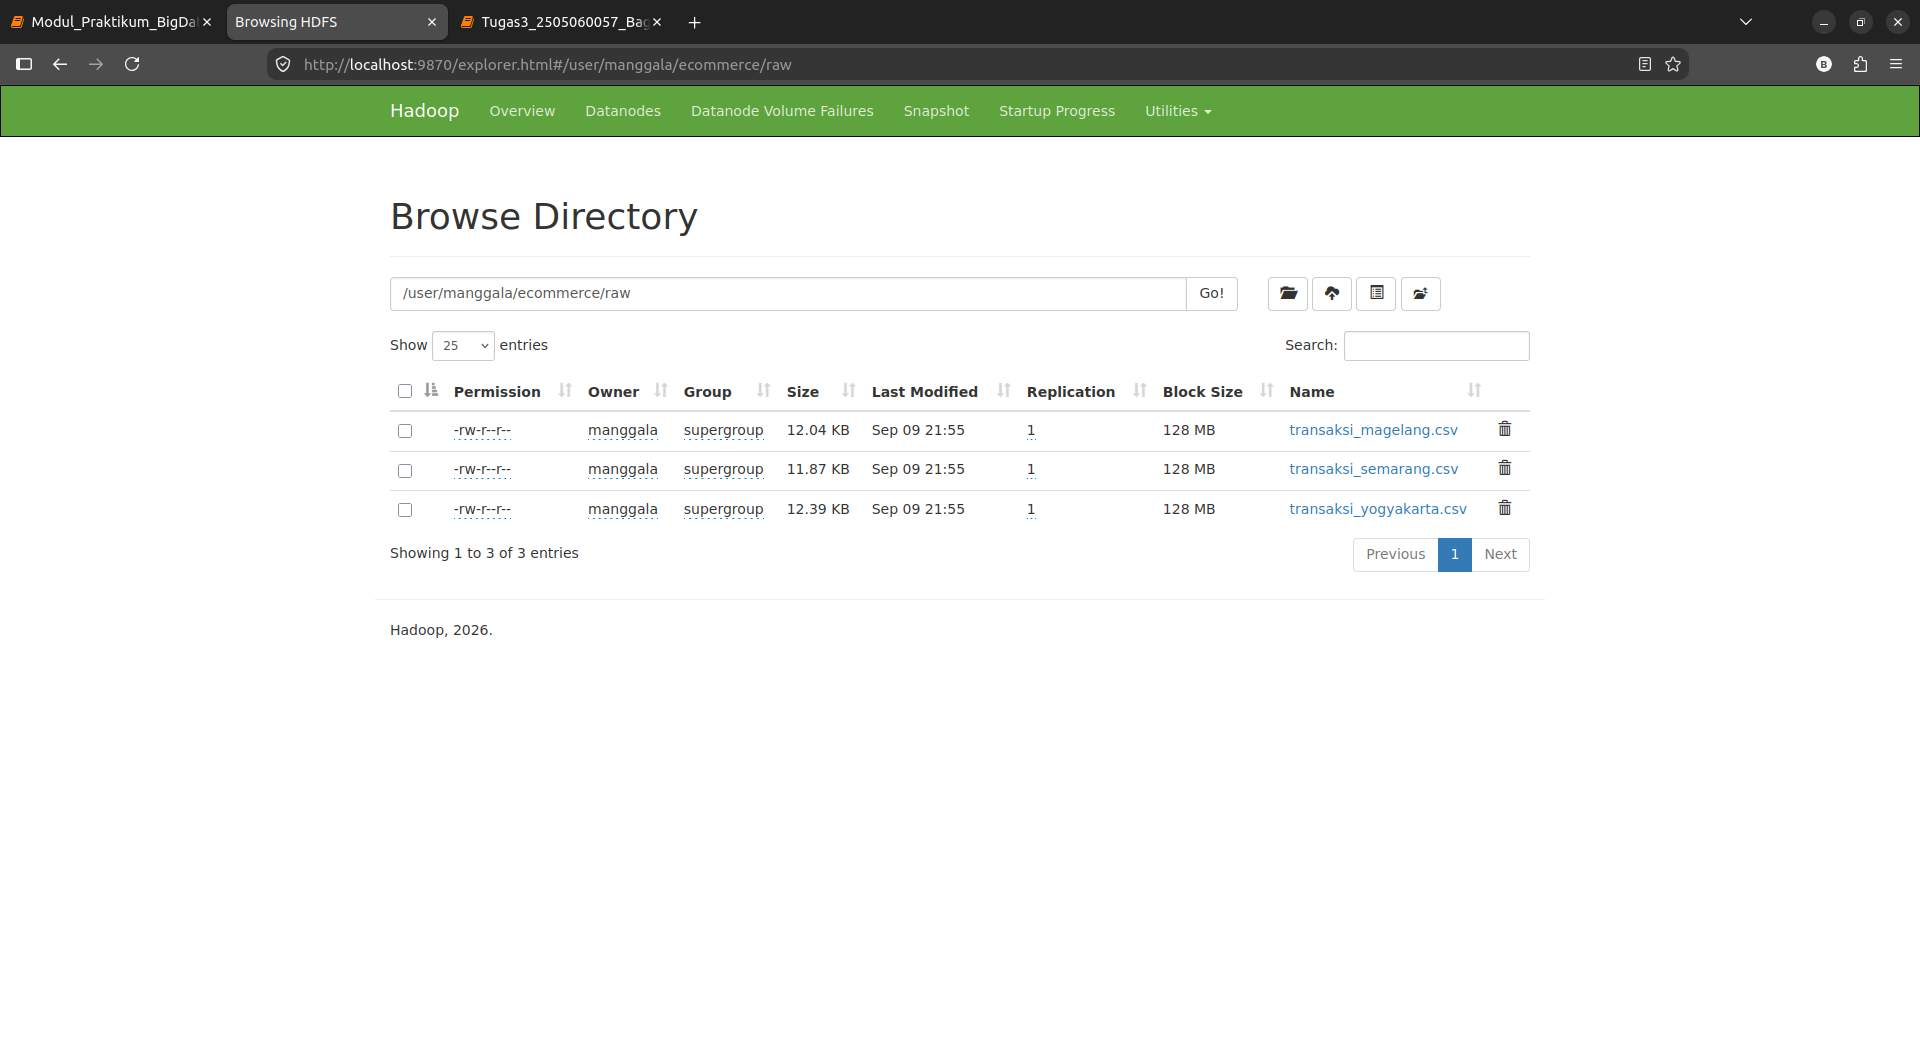

Menurut saya, menyimpan data raw dan processed di folder yang berbeda akan membuat pengelolaan data di HDFS menjadi lebih mudah. Data raw merupakan data asli yang belum diubah, sehingga sebaiknya tetap disimpan dan tidak dicampur dengan data yang sudah diolah. Dengan adanya pemisahan folder, kita bisa lebih mudah mengetahui mana data asli dan mana data hasil pengolahan. Selain itu, jika terjadi kesalahan saat proses pengolahan, data raw masih bisa digunakan kembali untuk melakukan proses dari awal. Hal ini juga mengurangi kemungkinan data asli tertimpa atau berubah tanpa sengaja. Jika semua data disimpan dalam satu folder, tentunya akan lebih sulit untuk membedakan dan mengelolanya, terutama ketika jumlah data sudah banyak. Jadi, menurut saya, pemisahan data raw dan processed membuat penyimpanan data menjadi lebih rapi, aman, dan lebih mudah digunakan untuk proses analisis selanjutnya.
